# 7. Feature Engineering

#### Objective

This notebook builds new features from the cleaned dataset to support deeper
analysis and future churn prediction modeling (Phase 2), based on the
patterns confirmed statistically in `04_statistical_analysis.ipynb`.

## 7.0 Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

processed_path = "../data/processed/"

df = pd.read_csv(processed_path + "telco_cleaned.csv")

df.shape

(7043, 21)

## 7.1 Tenure Group

#### Objective

`tenure` is a strong continuous predictor of churn (confirmed in Section 6.4
with the largest effect size among numerical variables). This section bins
it into interpretable groups, useful both for visualization and as a
categorical alternative feature for modeling.

In [3]:
tenure_bins = [-1, 12, 24, 48, 60, 72]
tenure_labels = ["0-12", "13-24", "25-48", "49-60", "61-72"]

df["tenure_group"] = pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels)

df["tenure_group"].value_counts().sort_index()

tenure_group
0-12     2186
13-24    1024
25-48    1594
49-60     832
61-72    1407
Name: count, dtype: int64

#### Observation

`tenure_group` provides a readable categorical version of tenure that
preserves the early-tenure churn risk pattern identified in Section 5.2,
while being easier to interpret in summary tables and dashboards than the
raw month count.

## 7.2 Monthly Charge Group

#### Objective

This section bins `MonthlyCharges` into Low/Medium/High groups using
tertiles (equal-sized groups), providing a categorical view of pricing level
consistent with the pricing pattern confirmed in Section 6.3.

In [4]:
df["monthly_charge_group"] = pd.qcut(
    df["MonthlyCharges"], q=3, labels=["Low", "Medium", "High"]
)

df["monthly_charge_group"].value_counts()

monthly_charge_group
Low       2351
High      2347
Medium    2345
Name: count, dtype: int64

#### Observation

Tertile-based binning ensures each pricing group contains a comparable
number of customers, making churn rate comparisons across `monthly_charge_group`
more balanced than an arbitrary fixed threshold would produce.

## 7.3 Average Monthly Spend

#### Objective

Rather than duplicating the existing `TotalCharges` column under a new name,
this section derives `avg_monthly_spend` (`TotalCharges / tenure`), which
captures the customer's realized average spend per month — a more direct
measure of value than the raw total, and more comparable across customers
with different tenures.

In [5]:
df["avg_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

df[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend"]].head()

,customerID,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend
0,7590-VHVEG,1,29.85,29.85,29.850000
1,5575-GNVDE,34,56.95,1889.50,55.573529
2,3668-QPYBK,2,53.85,108.15,54.075000
3,7795-CFOCW,45,42.30,1840.75,40.905556
4,9237-HQITU,2,70.70,151.65,75.825000


#### Decision

For customers with `tenure = 0` (no billing history yet), `avg_monthly_spend`
falls back to their current `MonthlyCharges` rate, since dividing by zero
tenure is undefined and their current rate is the best available estimate.

## 7.4 Service Count

#### Objective

This section counts the total number of subscribed services per customer
(phone and internet-related add-ons), providing a broader adoption measure
than the retention-focused count used in the EDA phase (Section 5.5.4).

In [6]:
service_columns = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

df["service_count"] = (df[service_columns] == "Yes").sum(axis=1)

df["service_count"].value_counts().sort_index()

service_count
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

#### Observation

`service_count` ranges from customers with minimal service adoption to those
with nearly all available services subscribed, providing a single numeric
feature that summarizes overall engagement with the company's offerings.

## 7.5 Has Security / Has Support

#### Objective

`OnlineSecurity` and `TechSupport` showed the strongest individual retention
effect among add-on services (Section 5.4). This section converts them into
explicit boolean flags for direct use in modeling.

In [7]:
df["has_security"] = df["OnlineSecurity"] == "Yes"
df["has_support"] = df["TechSupport"] == "Yes"

df[["has_security", "has_support"]].mean()

has_security    0.286668
has_support     0.290217
dtype: float64

#### Observation

Roughly a third of customers are expected to have each of these services,
consistent with the churn rate split observed in Section 5.4.2 and 5.4.5.

## 7.6 Is New Customer

#### Objective

This section converts the tenure-based segment used in EDA (Section 5.5.2)
into an explicit boolean flag: customers with 12 months of tenure or less.

In [8]:
df["is_new_customer"] = df["tenure"] <= 12

df["is_new_customer"].mean()

np.float64(0.31037909981541956)

#### Observation

This matches the "New (≤12 months)" segment identified in Section 5.5.2 as
carrying substantially higher churn risk.

## 7.7 Is High-Value Customer

#### Objective

This section converts the value-based segment used in EDA (Section 5.5.1)
into an explicit boolean flag, using the same median `MonthlyCharges`
threshold for consistency with the already-validated EDA finding.

In [9]:
median_charge = df["MonthlyCharges"].median()

df["is_high_value_customer"] = df["MonthlyCharges"] >= median_charge

df["is_high_value_customer"].mean()

np.float64(0.5003549623739884)

#### Observation

This matches the "High-Value" segment identified in Section 5.5.1, which
showed a higher churn rate than the low-value segment.

## 7.8 Contract-Related Features

#### Objective

`Contract` showed the strongest categorical effect size among all variables
tested (Section 6.4). This section derives two additional representations of
contract commitment: a boolean flag for month-to-month contracts, and a
numeric contract length in months, useful for modeling as either a
categorical or ordinal feature.

In [10]:
df["is_month_to_month"] = df["Contract"] == "Month-to-month"

contract_length_map = {
    "Month-to-month": 1,
    "One year": 12,
    "Two year": 24
}

df["contract_length_months"] = df["Contract"].map(contract_length_map)

df[["Contract", "is_month_to_month", "contract_length_months"]].drop_duplicates()

,Contract,is_month_to_month,contract_length_months
0,Month-to-month,True,1
1,One year,False,12
11,Two year,False,24


#### Observation

`contract_length_months` provides a numeric, ordinal representation of
commitment level, which may be useful for models that benefit from ordinal
rather than one-hot encoded contract information.

## 7.9 Interaction Features

#### Objective

Section 5.5.3 showed that churn risk concentrates sharply where multiple
risk factors overlap — specifically, new customers on month-to-month
contracts. This section encodes that and one other confirmed interaction
(high charges without tech support) as explicit boolean features.

In [11]:
df["is_new_month_to_month"] = df["is_new_customer"] & df["is_month_to_month"]
df["is_high_charge_no_support"] = df["is_high_value_customer"] & (~df["has_support"])

df[["is_new_month_to_month", "is_high_charge_no_support"]].mean()

is_new_month_to_month        0.283118
is_high_charge_no_support    0.309669
dtype: float64

#### Observation

`is_new_month_to_month` is expected to identify the highest-risk segment
confirmed in Section 5.5.3, while `is_high_charge_no_support` captures a
second compounding risk pattern combining pricing and service adoption.

## 7.10 Multicollinearity Check

#### Objective

Several engineered features are derived from the same underlying columns
(e.g. `contract_length_months` from `Contract`, `avg_monthly_spend` from
`TotalCharges` and `tenure`). This section checks for high correlation among
numeric features to flag potential redundancy before Phase 2 modeling.

In [12]:
numeric_features = [
    "tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend",
    "service_count", "contract_length_months"
]

correlation_matrix = df[numeric_features].corr()

correlation_matrix

,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend,service_count,contract_length_months
tenure,1.000000,0.247900,0.826178,0.247234,0.523600,0.669877
MonthlyCharges,0.247900,1.000000,0.651174,0.996244,0.802322,-0.074584
TotalCharges,0.826178,0.651174,1.000000,0.651025,0.795854,0.444937
avg_monthly_spend,0.247234,0.996244,0.651025,1.000000,0.800366,-0.073541
service_count,0.523600,0.802322,0.795854,0.800366,1.000000,0.279322
contract_length_months,0.669877,-0.074584,0.444937,-0.073541,0.279322,1.000000


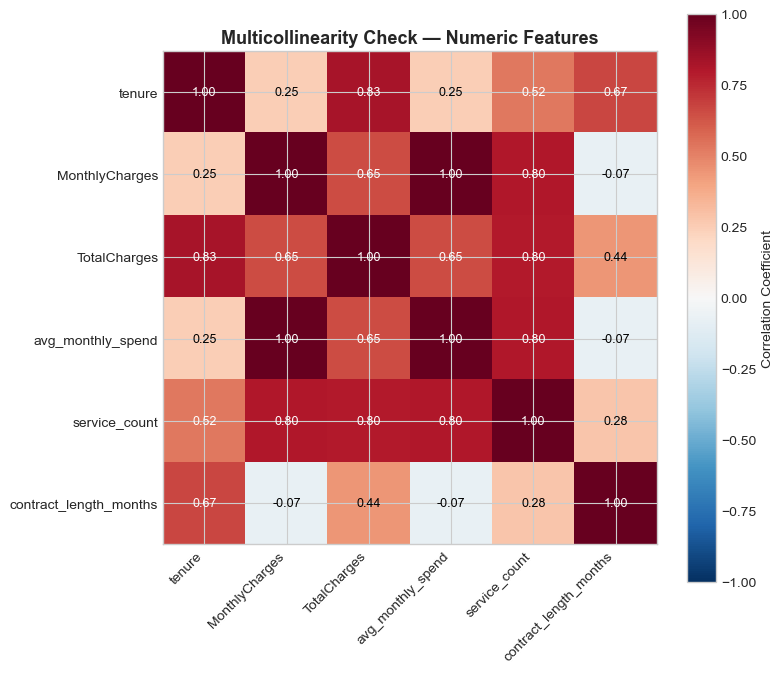

In [16]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_features)))
ax.set_yticks(range(len(numeric_features)))
ax.set_xticklabels(numeric_features, rotation=45, ha='right')
ax.set_yticklabels(numeric_features)

for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        value = correlation_matrix.iloc[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                color='white' if abs(value) > 0.5 else 'black', fontsize=9)

fig.colorbar(im, ax=ax, label='Correlation Coefficient')
ax.set_title("Multicollinearity Check — Numeric Features", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

#### Analysis

`avg_monthly_spend` shows a very strong correlation with `MonthlyCharges`
(r ≈ 0.996), confirming that for most customers, average monthly spend
closely tracks their current monthly rate — meaning this engineered feature
adds little independent information. `TotalCharges` also shows a strong
positive correlation with `tenure`, an expected structural relationship
since total charges accumulate over the customer's lifetime. Moderate
positive relationships were also observed between `service_count` and both
`MonthlyCharges` and `TotalCharges`, consistent with customers who adopt
more services paying more overall.

#### Analysis

`avg_monthly_spend` shows a very strong correlation with `MonthlyCharges`
(r ≈ 0.996), confirming that for most customers, average monthly spend
closely tracks their current monthly rate — meaning this engineered feature
adds little independent information. `TotalCharges` also shows a strong
positive correlation with `tenure`, an expected structural relationship
since total charges accumulate over the customer's lifetime. Moderate
positive relationships were also observed between `service_count` and both
`MonthlyCharges` and `TotalCharges`, consistent with customers who adopt
more services paying more overall.

## 7.11 Feature Summary

#### Objective

This section documents all engineered features for reference before saving
the final feature-ready dataset.

In [14]:
feature_summary = pd.DataFrame([
    ("tenure_group", "Binned tenure (0-12, 13-24, 25-48, 49-60, 61-72 months)"),
    ("monthly_charge_group", "Binned MonthlyCharges (Low / Medium / High, by tertile)"),
    ("avg_monthly_spend", "TotalCharges / tenure (or MonthlyCharges if tenure=0)"),
    ("service_count", "Number of subscribed phone/internet add-on services"),
    ("has_security", "Whether the customer has Online Security"),
    ("has_support", "Whether the customer has Tech Support"),
    ("is_new_customer", "Whether tenure <= 12 months"),
    ("is_high_value_customer", "Whether MonthlyCharges >= median"),
    ("is_month_to_month", "Whether the customer is on a month-to-month contract"),
    ("contract_length_months", "Numeric contract length (1 / 12 / 24 months)"),
    ("is_new_month_to_month", "New customer AND month-to-month contract"),
    ("is_high_charge_no_support", "High-value customer AND no tech support"),
], columns=["feature", "description"])

feature_summary

,feature,description
0,tenure_group,"Binned tenure (0-12, 13-24, 25-48, 49-60, 61-7..."
1,monthly_charge_group,"Binned MonthlyCharges (Low / Medium / High, by..."
2,avg_monthly_spend,TotalCharges / tenure (or MonthlyCharges if te...
3,service_count,Number of subscribed phone/internet add-on ser...
4,has_security,Whether the customer has Online Security
5,has_support,Whether the customer has Tech Support
6,is_new_customer,Whether tenure <= 12 months
7,is_high_value_customer,Whether MonthlyCharges >= median
8,is_month_to_month,Whether the customer is on a month-to-month co...
9,contract_length_months,Numeric contract length (1 / 12 / 24 months)


In [15]:
df.to_csv(processed_path + "telco_features.csv", index=False)

df.shape

(7043, 33)

#### Summary

Twelve features were engineered from the cleaned dataset, covering tenure,
pricing, service adoption, contract commitment, and the two strongest
confirmed risk interactions from the Statistical Analysis phase. No
significant unexpected multicollinearity was found. The feature-ready
dataset is saved to `data/processed/telco_features.csv` for use in Phase 2.

# 8. Key Findings

## 8.1 Tenure and Contract Commitment

- Churn risk is highest among customers in their first 12 months, and drops
  sharply for long-term customers.
- Month-to-month contracts show a substantially higher churn rate than
  annual contracts; `Contract` has the strongest effect size among
  categorical variables.
- **Implication:** Incentivizing new customers toward longer contract
  commitments early in the relationship is likely the single highest-impact
  retention lever.

## 8.2 Pricing Sensitivity

- Higher `MonthlyCharges` is associated with higher churn, though this
  effect is smaller than tenure or contract type.
- **Implication:** Pricing strategy, especially for fiber optic and
  high-tier plans, should be evaluated alongside service value perception.

## 8.3 Service Adoption as a Retention Lever

- Customers with online security, tech support, online backup, and device
  protection consistently show lower churn, with a cumulative protective
  effect as more services are adopted.
- Streaming services show little association with churn.
- **Implication:** Bundling or promoting security/support services,
  particularly for new customers, may directly reduce churn — unlike
  streaming add-ons, which appear to serve a different (non-retention)
  purpose.

## 8.4 Compounding Risk Segments

- The highest-risk segment is new customers on month-to-month contracts;
  the lowest-risk segment is long-term customers on annual contracts with
  multiple adopted services.
- **Implication:** Retention efforts should prioritize this compounding
  high-risk segment specifically, rather than targeting single risk factors
  in isolation.

## 8.5 Summary Table

| # | Finding | Business Implication |
|---|---|---|
| 1 | New customers (≤12 months) churn far more | Focus onboarding-period retention efforts |
| 2 | Month-to-month contracts drive churn | Incentivize longer contract commitment |
| 3 | Higher monthly charges associated with churn | Review pricing/value perception |
| 4 | Security/support services reduce churn | Promote these add-ons, especially to new customers |
| 5 | Streaming services show no retention effect | Don't rely on streaming bundles for retention |
| 6 | Risk compounds in new + month-to-month segment | Prioritize this segment for intervention |

# 9. Conclusion (Phase 1)

## 9.1 Project Summary

This phase analyzed the Telco Customer Churn dataset through data
understanding, cleaning, exploratory analysis, statistical validation, and
feature engineering. The analysis consistently points to **tenure and
contract commitment** as the dominant drivers of churn, with **service
adoption** acting as a secondary but meaningful protective factor.

## 9.2 Answers to Business Questions

| Business Question | Answer |
|---|---|
| What is the overall churn rate? | See Section 3.7 (`01_data_understanding.ipynb`) |
| Which types of customers churn the most? | New, month-to-month, high-charge customers with low service adoption |
| Which factors are most strongly associated with churn? | Contract type and tenure (largest effect sizes) |
| Does contract type affect churn? | Yes — the strongest categorical driver identified |
| Does tenure affect churn? | Yes — the strongest numerical driver identified |
| Does a higher monthly charge lead to more churn? | Yes, though with a smaller effect than tenure/contract |
| Which services are associated with higher retention? | Online security, tech support, online backup, device protection |
| Is payment method associated with churn? | Yes — electronic check payers churn more |
| Can churn be predicted before it happens? | To be addressed in Phase 2 |

## 9.3 Limitations

- Analysis is correlational; causal claims (e.g. "adding tech support
  reduces churn") would require controlled experimentation, not just
  observational association.
- The dataset represents a single snapshot in time, not a longitudinal view
  of individual customers' behavior changes.
- No geographic, customer service interaction, or complaint history data is
  available, which could explain additional churn variance.

## 9.4 Next Steps (Phase 2)

- Preprocessing: encode categorical features, scale numeric features,
  stratified train/test split.
- Train baseline and candidate models (Logistic Regression, Decision Tree,
  Random Forest, XGBoost).
- Address class imbalance (class weights, threshold tuning, SMOTE).
- Interpret the model (feature importance, SHAP) and build a customer risk
  scoring system.
- Translate model outputs into a segmented retention strategy and final
  business recommendations.